# 061 — Round 4: grouped k-fold evaluation

Reads whatever `060_kfold_training.ipynb` has produced under `models/kfold/fold_*/`
and, for **each model in `MODELS`** (§1), reports:

- **§2 — per-fold held-out pixel metrics** (`loss`/`mae`/… on that fold's held-out
  real artworks, scored by that fold's own model) → **mean ± std** across folds. The
  variance estimate `fixing.md` #4 is about.
- **§3 — detection on `GT01`-`GT03`**: `structural delta` AUROC + stroke coherence
  (and, for NLL models, `structural z` = the delta divided by the fold's learned
  `σ`), **per fold-model** and for the **k-fold ensemble** (mean of the fold `μ`s).
  The GT paintings are external to every fold, so each fold-model is a genuine
  held-out predictor for them.
- **§4 — headline** numbers for the write-up.

`MODELS` mirrors `060`'s `SELECTED`. `attention_unet_nll` is the locked Round 4 model
(fully evaluated — see §6). Deterministic models contribute `structural delta` only
(no `σ`, so no `structural z`).

Runs with **≥ 1 fold** of a model; with `< K` folds the mean±std is over what exists,
with a warning. Re-run as more folds finish.

Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports — the `C4`/`C5` detection toolkit plus the k-fold split.

In [2]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import laplace_sigma_from_scale, structural_zscore
from scripts.config import settings
from scripts.dataset import build_dataset, load_image_pairs, pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.detection import evaluate_detection
from scripts.kfold import fold_artwork_groups, grouped_kfold_splits
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization import plot_gt_signal_gallery

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Models to evaluate, and which folds exist

`MODELS` mirrors `060`'s `SELECTED` — uncomment the ones whose folds you have
trained. `NLL_MODELS` decides the loader (`load_model_nll` vs `load_model`) and
whether `structural z` is available.

In [3]:
K = settings.KFOLD_K
KFOLD_DIR = settings.MODELS_DIR / "kfold"

# Uncomment the models whose k-fold checkpoints you have trained in 060.
MODELS = [
    "attention_unet_nll",
    # "unet_nll",
    "resunet_nll",
    # "efficientnet_unet_nll",
    # "efficientnet_unet_nll_ft",
    # "unet",
    # "resunet",
    # "attention_unet",
    # "unet_v2",
    # "unet_restormer",
    # "unet_dilated",
    # "unet_v2_dilated",
    # "efficientnet_unet",
    # "efficientnet_unet_ft",
]

NLL_MODELS = {
    "unet_nll", "resunet_nll", "attention_unet_nll",
    "efficientnet_unet_nll", "efficientnet_unet_nll_ft",
}


def is_nll(name):
    return name in NLL_MODELS


def load_fold_model(name, fold):
    """Load model `name`'s checkpoint for `fold` from models/kfold/fold_<fold>/."""
    md = KFOLD_DIR / f"fold_{fold}"
    if is_nll(name):
        return load_model_nll(name, model_dir=md, loss_name="laplace_nll", beta=settings.NLL_BETA)
    return load_model(name, model_dir=md)


def folds_available(name):
    return [f for f in range(K)
            if (KFOLD_DIR / f"fold_{f}" / name / "best_model.keras").exists()]


pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
held_out = fold_artwork_groups(pairs, k=K, seed=settings.KFOLD_SEED)
splits = grouped_kfold_splits(pairs, k=K, seed=settings.KFOLD_SEED)

MODEL_FOLDS = {}
for name in MODELS:
    av = folds_available(name)
    MODEL_FOLDS[name] = av
    tag = "NLL" if is_nll(name) else "det"
    note = "" if len(av) == K else f"  <-- only {len(av)}/{K}, stats over these"
    print(f"{name:<26} ({tag})  folds {av}{note}")

MODELS = [m for m in MODELS if MODEL_FOLDS[m]]
if not MODELS:
    raise RuntimeError("No fold checkpoints for any model in MODELS — run 060 first.")

attention_unet_nll         (NLL)  folds [0, 1, 2]
resunet_nll                (NLL)  folds [0, 1, 2]


## 2. Per-fold held-out pixel metrics

For every model: each fold's checkpoint evaluated on its own held-out real artworks
(full-resolution, `batch_size=1`). The spread across folds is the point of the round.
Metric names differ between families (NLL reports `loss` = Laplace NLL; deterministic
reports the `combined_loss`), so the table just shows whatever `model.evaluate`
returns.

In [4]:
pixel_rows = {}  # pixel_rows[name][fold] = {metric: value}

for name in MODELS:
    pixel_rows[name] = {}
    for fold in MODEL_FOLDS[name]:
        model = load_fold_model(name, fold)
        _, val_pairs = splits[fold]
        val_ds = build_dataset(val_pairs, batch_size=1, augment=False, shuffle=False)
        scores = dict(zip(model.metrics_names, model.evaluate(val_ds, verbose=0)))
        pixel_rows[name][fold] = scores
        del model, val_ds
        gc.collect()
        tf.keras.backend.clear_session()

    rows = pixel_rows[name]
    av = MODEL_FOLDS[name]
    keys = list(next(iter(rows.values())))
    print(f"\n=== {name} ===")
    print(f"{'metric':<16}" + "".join(f"fold {f}".rjust(12) for f in av) + f"{'mean':>12}{'std':>10}")
    print("-" * (16 + 12 * len(av) + 22))
    for k in keys:
        vals = np.array([rows[f][k] for f in av])
        print(f"{k:<16}" + "".join(f"{rows[f][k]:.4f}".rjust(12) for f in av)
              + f"{vals.mean():>12.4f}{vals.std():>10.4f}")

2026-08-28 09:01:03.781247: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-28 09:01:03.781266: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-28 09:01:03.781270: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-28 09:01:03.781280: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 09:01:03.781288: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-08-28 09:01:04.767088: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



=== attention_unet_nll ===
metric                fold 0      fold 1      fold 2        mean       std
--------------------------------------------------------------------------
loss                 -0.3844     -0.4451     -0.4424     -0.4240    0.0280
compile_metrics       0.1283      0.0983      0.1040      0.1102    0.0130

=== resunet_nll ===
metric                fold 0      fold 1      fold 2        mean       std
--------------------------------------------------------------------------
loss                 -0.3811     -0.4583     -0.4465     -0.4286    0.0339
compile_metrics       0.1048      0.0817      0.0892      0.0919    0.0096


## 3. Detection on the GT paintings

`GT01`/`GT02`/`GT03` are outside every fold, so each fold-model is a held-out
predictor for them. Signals from the fold `μ`: `structural delta` (`1 - local SSIM
structure`) always, plus `structural z` (that ÷ the fold's learned `σ`) for NLL
models only. Scored per fold-model and for the **ensemble** = the pixel-wise mean of
the available fold `μ`s (and, for `structural z`, the mean of their `σ`s).

In [5]:
TEST_RGB = project_root / "data" / "test" / "rgb"
TEST_IR = project_root / "data" / "test" / "ir"
ANN = project_root / "data" / "test" / "annotations"
GT_STEMS = sorted(p.name.removesuffix("_Map.png") for p in ANN.glob("*_Map.png"))


def _find(stem, folder):
    for ext in (".jpg", ".png", ".jpeg", ".tif", ".tiff"):
        if (folder / f"{stem}{ext}").exists():
            return folder / f"{stem}{ext}"
    return None


def load_triplet(stem):
    rgb = np.array(Image.open(_find(stem, TEST_RGB)).convert("RGB"), np.float32) / 255.0
    ir = np.array(Image.open(_find(stem, TEST_IR)).convert("L"), np.float32) / 255.0
    mask = np.array(Image.open(ANN / f"{stem}_Map.png").convert("L")) > 127
    return rgb, ir, mask


def predict(model, name, rgb, hw):
    """Return (mu, sigma) — sigma is None for deterministic models."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = hw
    p = model.predict(padded[tf.newaxis, ...], verbose=0)[0, :h, :w, :]
    mu = p[..., 0]
    sigma = laplace_sigma_from_scale(np.exp(p[..., 1])) if is_nll(name) else None
    return mu, sigma


gt_data = {s: load_triplet(s) for s in GT_STEMS}
# preds[name][stem][fold] = (mu, sigma)
preds = {name: {s: {} for s in GT_STEMS} for name in MODELS}

for name in MODELS:
    for fold in MODEL_FOLDS[name]:
        model = load_fold_model(name, fold)
        for s in GT_STEMS:
            rgb, ir, _ = gt_data[s]
            preds[name][s][fold] = predict(model, name, rgb, ir.shape)
        del model
        gc.collect()
        tf.keras.backend.clear_session()
    print(f"{name}: predicted {GT_STEMS} with folds {MODEL_FOLDS[name]}")

attention_unet_nll: predicted ['GT01', 'GT02', 'GT03'] with folds [0, 1, 2]
resunet_nll: predicted ['GT01', 'GT02', 'GT03'] with folds [0, 1, 2]


In [6]:
def signals_from(ir, mu, sigma):
    d = analyze_delta(ir, mu)
    sig = {"structural delta": d.structural_delta}
    if sigma is not None:
        sig["structural z"] = structural_zscore(d.structural_delta, sigma)
    return sig


def score(sig, mask):
    return evaluate_detection(sig, mask).auroc, stroke_coherence(sig).coherence


det_rows = {}  # det_rows[name][(scope, signal)] = {stem: (auroc, coherence)}
for name in MODELS:
    av = MODEL_FOLDS[name]
    r = {}
    for s in GT_STEMS:
        _, ir, mask = gt_data[s]
        for fold in av:
            mu, sigma = preds[name][s][fold]
            for sn, sig in signals_from(ir, mu, sigma).items():
                r.setdefault((f"fold {fold}", sn), {})[s] = score(sig, mask)
        mu_e = np.mean([preds[name][s][f][0] for f in av], axis=0)
        sig_e = (np.mean([preds[name][s][f][1] for f in av], axis=0)
                 if is_nll(name) else None)
        for sn, sig in signals_from(ir, mu_e, sig_e).items():
            r.setdefault(("ensemble", sn), {})[s] = score(sig, mask)
    det_rows[name] = r

    signals = ["structural delta"] + (["structural z"] if is_nll(name) else [])
    for signal in signals:
        print(f"\n=== {name} — {signal} ===")
        print(f"{'scope':<12}" + "".join(f"{s} AUROC".rjust(14) for s in GT_STEMS)
              + f"{'mean AUROC':>12}{'mean coh':>10}")
        print("-" * (12 + 14 * len(GT_STEMS) + 22))
        for scope in [f"fold {f}" for f in av] + ["ensemble"]:
            d = r[(scope, signal)]
            au = np.array([d[s][0] for s in GT_STEMS])
            co = np.array([d[s][1] for s in GT_STEMS])
            print(f"{scope:<12}" + "".join(f"{d[s][0]:.3f}".rjust(14) for s in GT_STEMS)
                  + f"{au.mean():>12.3f}{co.mean():>10.3f}")


=== attention_unet_nll — structural delta ===
scope           GT01 AUROC    GT02 AUROC    GT03 AUROC  mean AUROC  mean coh
----------------------------------------------------------------------------
fold 0               0.801         0.686         0.569       0.686     0.317
fold 1               0.794         0.660         0.595       0.683     0.333
fold 2               0.730         0.665         0.606       0.667     0.326
ensemble             0.802         0.680         0.618       0.700     0.350

=== attention_unet_nll — structural z ===
scope           GT01 AUROC    GT02 AUROC    GT03 AUROC  mean AUROC  mean coh
----------------------------------------------------------------------------
fold 0               0.819         0.678         0.596       0.698     0.303
fold 1               0.781         0.665         0.685       0.710     0.332
fold 2               0.778         0.676         0.617       0.690     0.320
ensemble             0.820         0.684         0.653       0.

## 4. Headline

The numbers for `evaluation.md` §8: per-model, mean ± std of the mean-over-GT AUROC
**across fold-models**, and the k-fold ensemble's value.

In [7]:
for name in MODELS:
    av = MODEL_FOLDS[name]
    print(f"\nmodel: {name}   folds: {av}   (GT mean over {GT_STEMS})")
    signals = ["structural delta"] + (["structural z"] if is_nll(name) else [])
    for signal in signals:
        per_fold = np.array([
            np.mean([det_rows[name][(f"fold {f}", signal)][s][0] for s in GT_STEMS])
            for f in av
        ])
        ens = np.mean([det_rows[name][("ensemble", signal)][s][0] for s in GT_STEMS])
        print(f"  {signal:<18} AUROC per fold {np.round(per_fold, 3).tolist()}  "
              f"-> {per_fold.mean():.3f} ± {per_fold.std():.3f}   ensemble {ens:.3f}")
    for k in list(next(iter(pixel_rows[name].values()))):
        v = np.array([pixel_rows[name][f][k] for f in av])
        print(f"  {k:<18} held-out per fold {np.round(v, 4).tolist()}  "
              f"-> {v.mean():.4f} ± {v.std():.4f}")


model: attention_unet_nll   folds: [0, 1, 2]   (GT mean over ['GT01', 'GT02', 'GT03'])
  structural delta   AUROC per fold [0.686, 0.683, 0.667]  -> 0.678 ± 0.008   ensemble 0.700
  structural z       AUROC per fold [0.698, 0.71, 0.69]  -> 0.699 ± 0.008   ensemble 0.719
  loss               held-out per fold [-0.3844, -0.4451, -0.4424]  -> -0.4240 ± 0.0280
  compile_metrics    held-out per fold [0.1283, 0.0983, 0.104]  -> 0.1102 ± 0.0130

model: resunet_nll   folds: [0, 1, 2]   (GT mean over ['GT01', 'GT02', 'GT03'])
  structural delta   AUROC per fold [0.678, 0.659, 0.684]  -> 0.674 ± 0.011   ensemble 0.692
  structural z       AUROC per fold [0.726, 0.701, 0.72]  -> 0.716 ± 0.011   ensemble 0.728
  loss               held-out per fold [-0.3811, -0.4583, -0.4465]  -> -0.4286 ± 0.0339
  compile_metrics    held-out per fold [0.1048, 0.0817, 0.0892]  -> 0.0919 ± 0.0096


## 5. Visual — the ensemble signal on each GT painting, per model

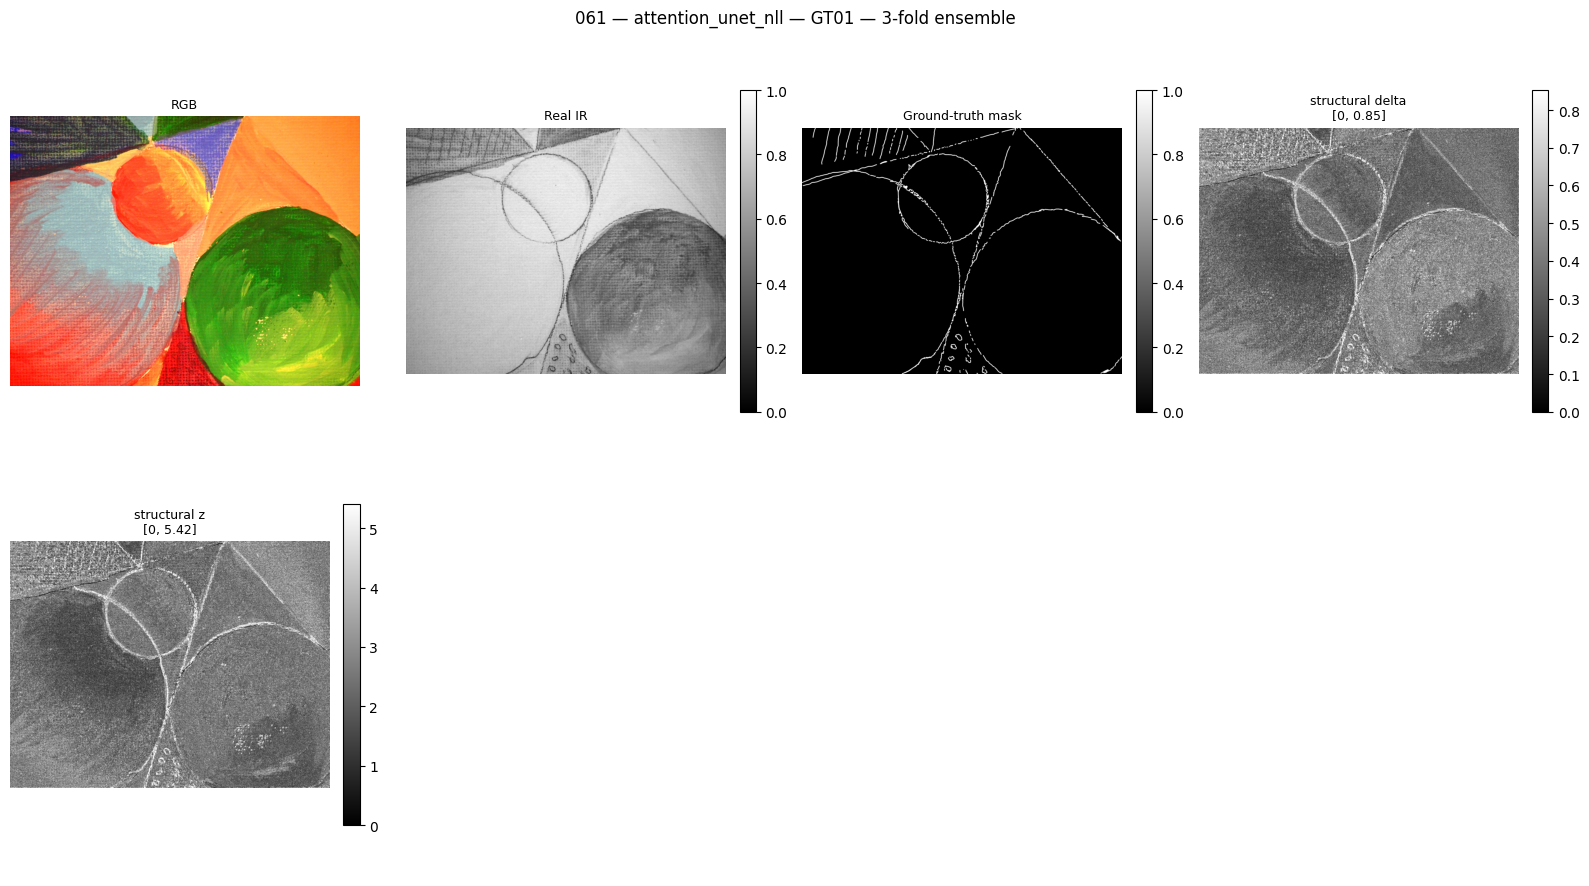

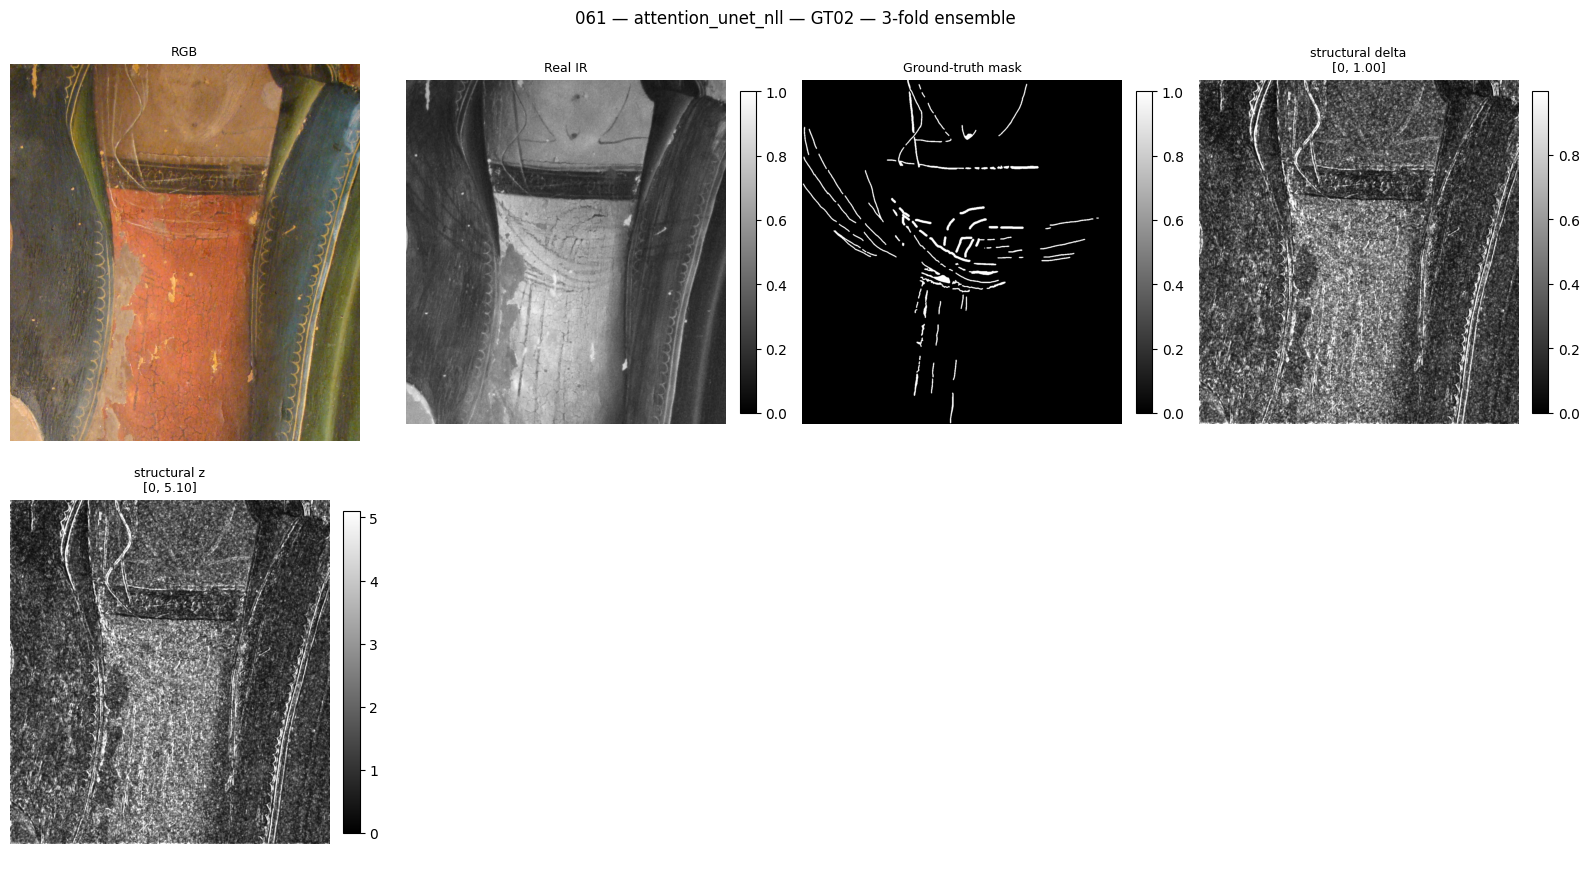

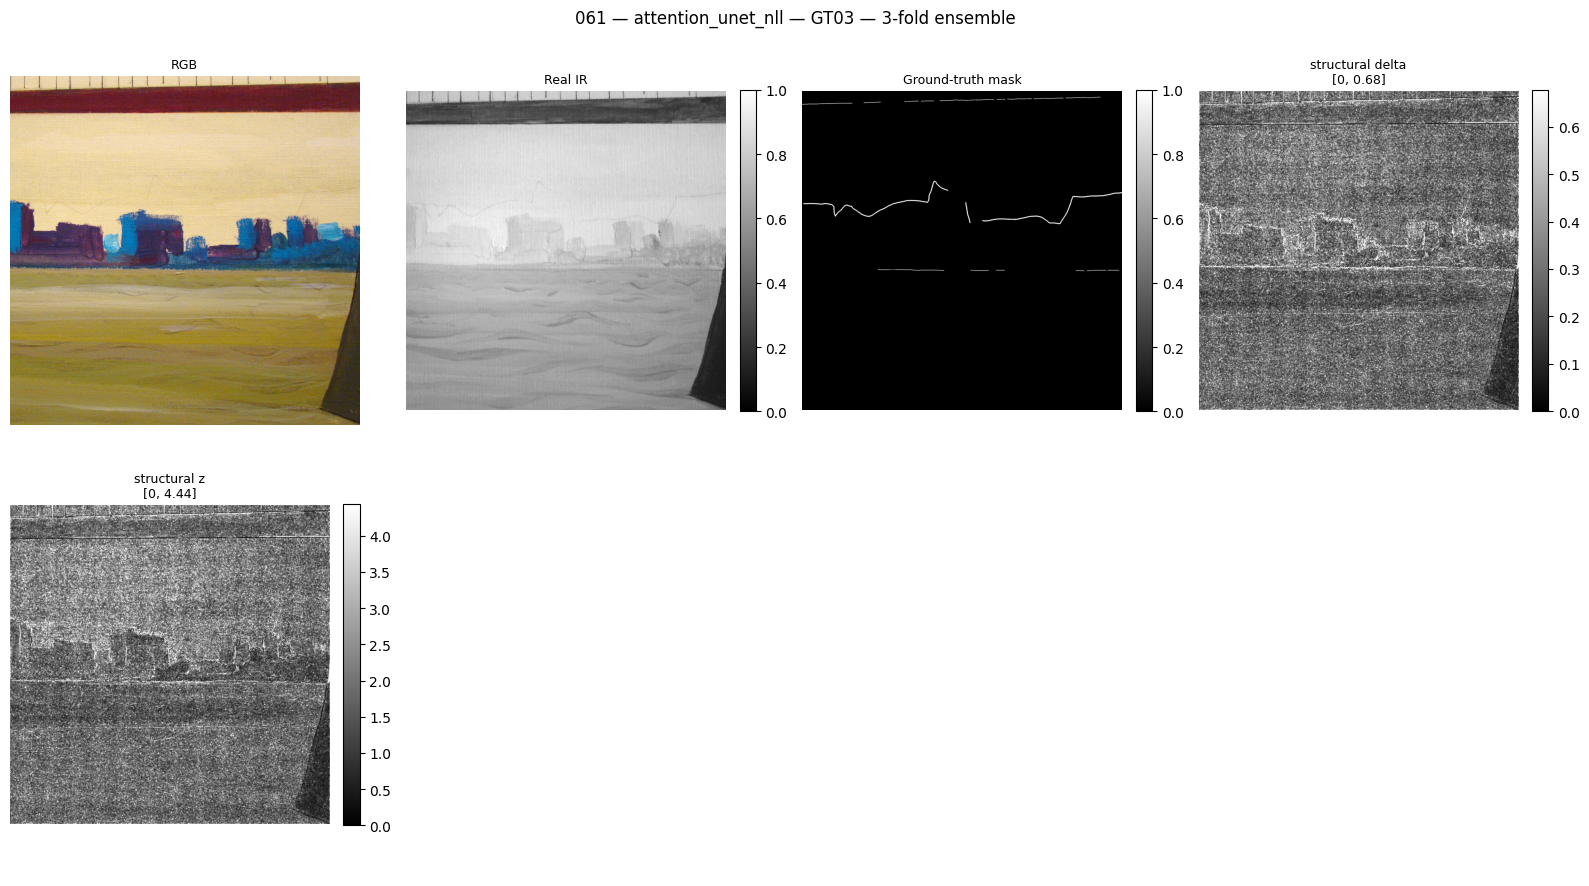

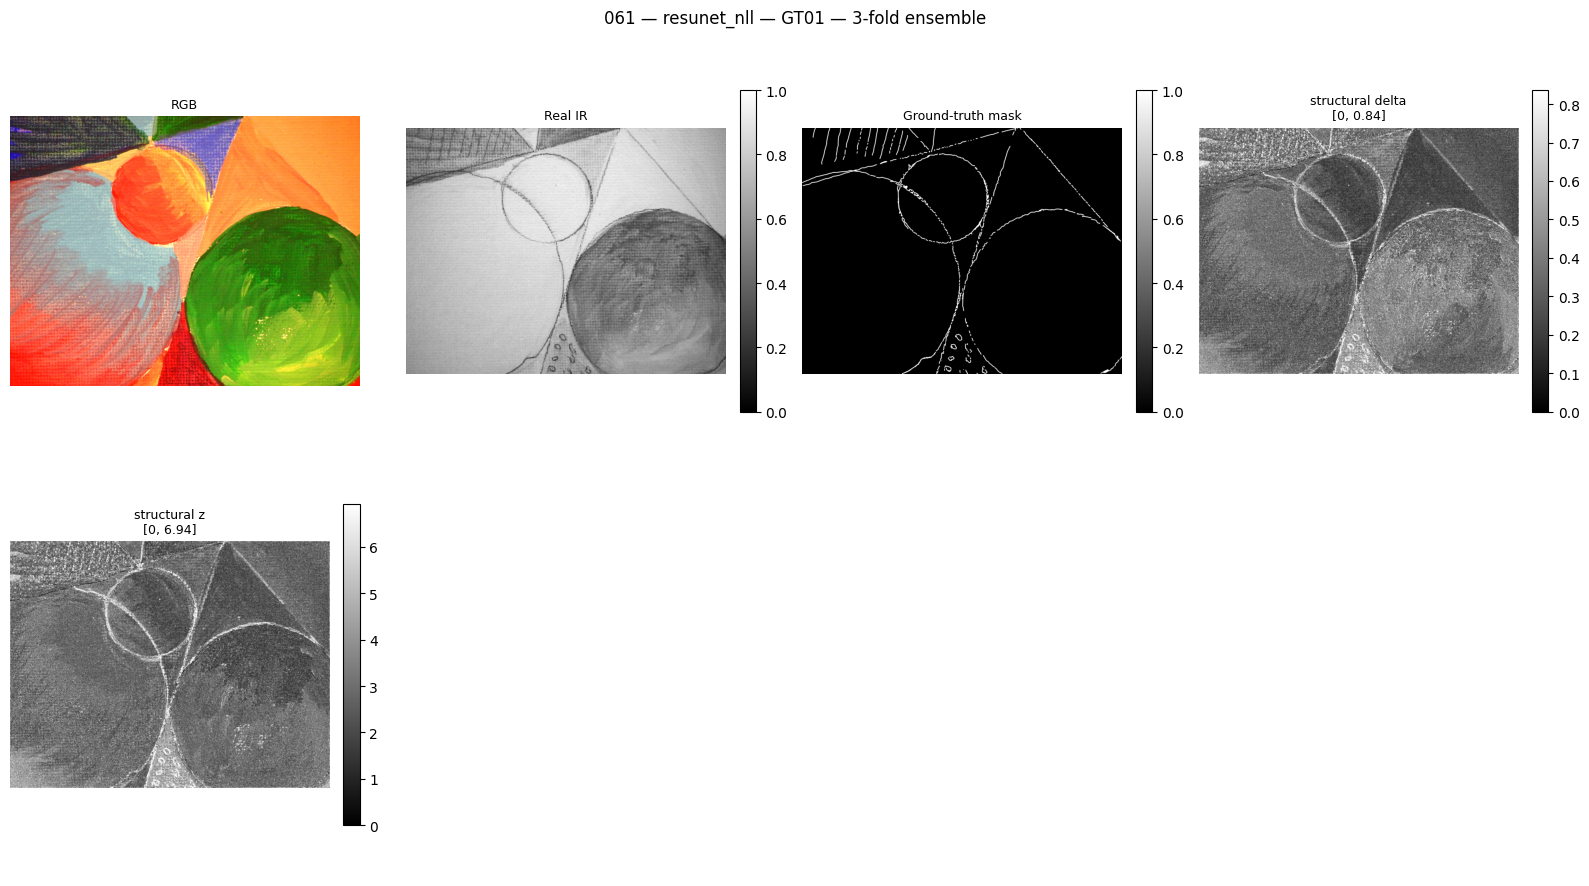

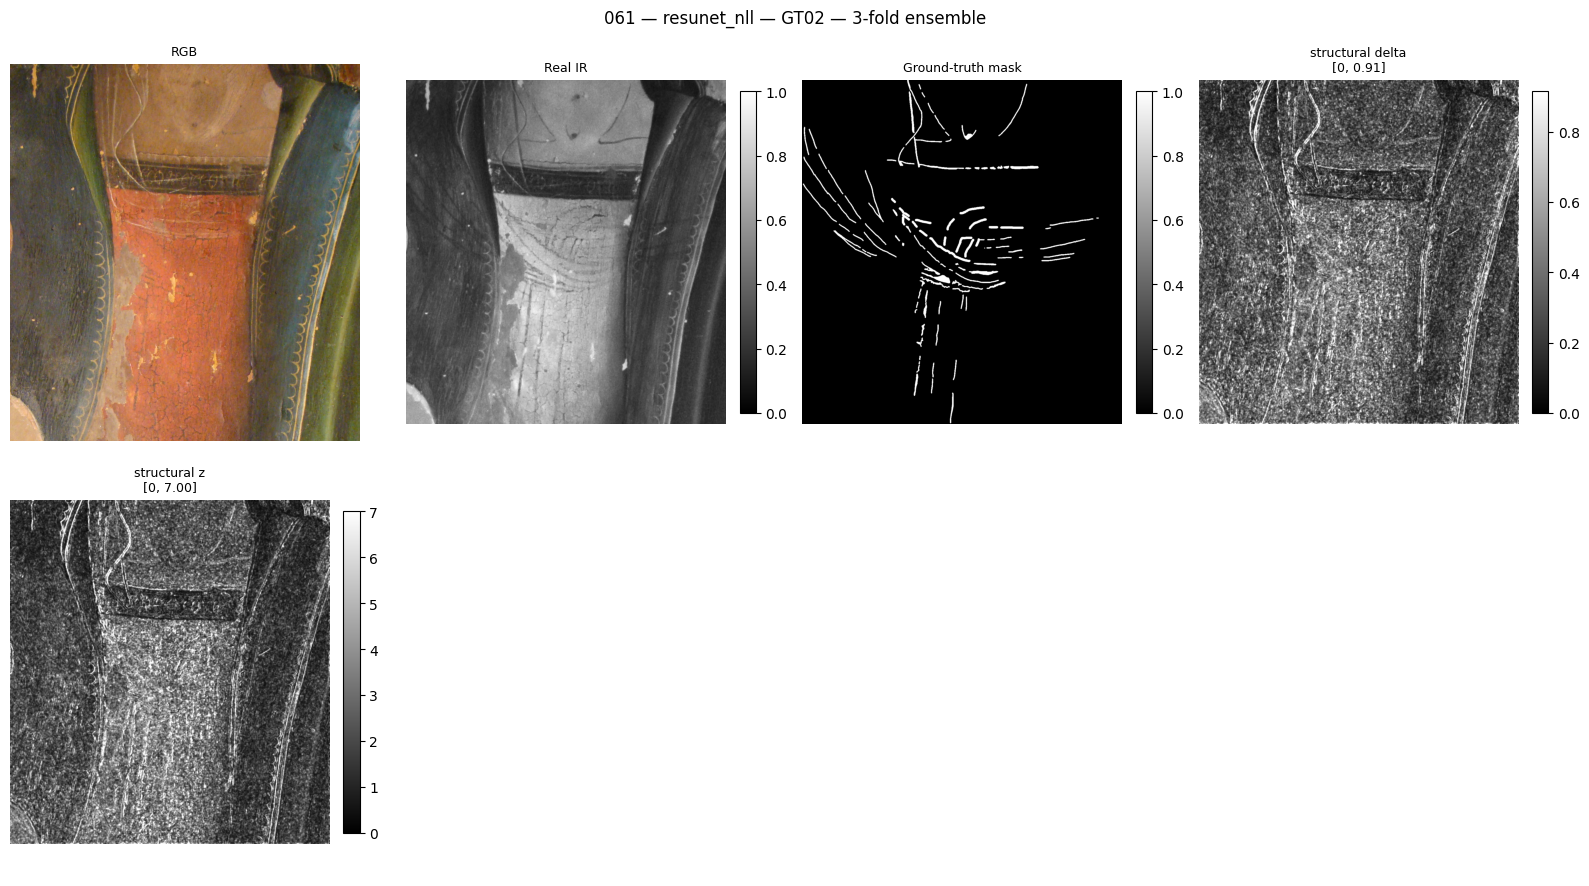

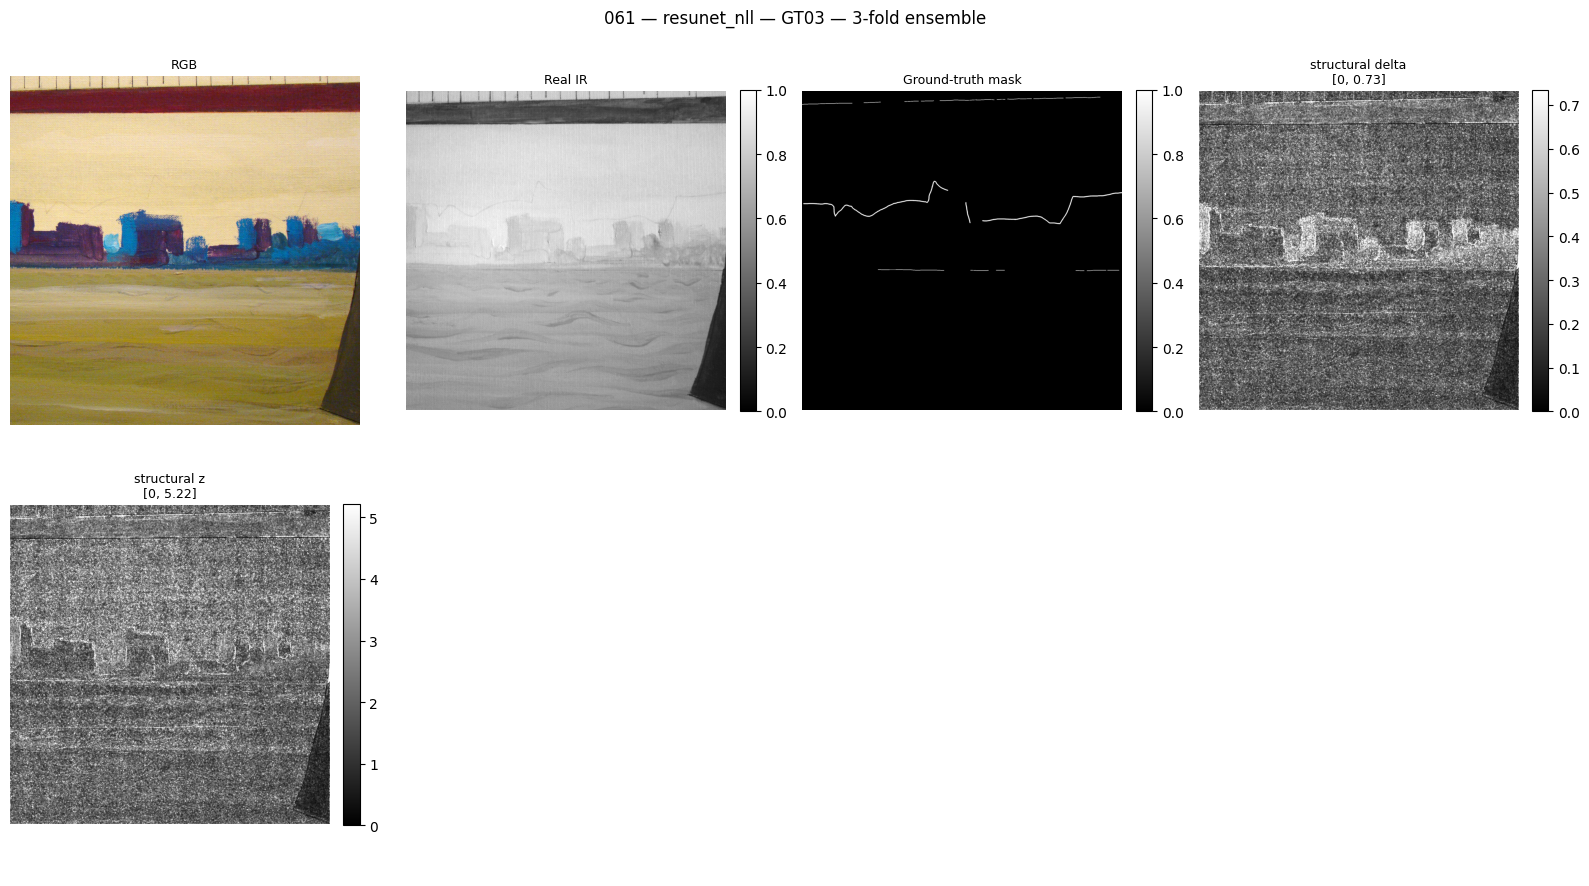

In [8]:
for name in MODELS:
    av = MODEL_FOLDS[name]
    for s in GT_STEMS:
        rgb, ir, mask = gt_data[s]
        mu_e = np.mean([preds[name][s][f][0] for f in av], axis=0)
        sig_e = (np.mean([preds[name][s][f][1] for f in av], axis=0)
                 if is_nll(name) else None)
        panels = signals_from(ir, mu_e, sig_e)
        fig = plot_gt_signal_gallery(
            rgb, ir, mask, panels,
            title=f"061 — {name} — {s} — {len(av)}-fold ensemble",
        )
        plt.show()
        plt.close(fig)

## 6. Conclusion

Grouped k-fold, k=3, β=0.5, real artworks grouped by ID (no section leakage), mockups
in every train set, GT paintings external to every fold. Two NLL models run so far.

### `attention_unet_nll` — the locked Round 4 model (2026-08-27)

- **Stable across folds** — early-stopped epoch 22 / 38 / 24, best `val_loss`
  −0.3844 / −0.4451 / −0.4424. Fold 0 (held-out `mano`/`mod`/`natmorta2`/`q2`/`q3`/
  `santo`/`sch02`/`sch03`/`volto`) is the hardest split; folds 1–2 agree tightly.
- **Held-out pixel spread (§2):** `val_loss` −0.4240 ± 0.0280, MAE 0.110 ± 0.013.
- **Detection AUROC (§3/§4), mean over GT01–03:** `structural delta` 0.678 ± 0.008
  per fold / **0.700** ensemble; `structural z` 0.699 ± 0.008 per fold / **0.719**
  ensemble.
- Matches the single-split `031`/`C4` numbers (`structural delta` ≈ 0.70,
  `structural z` ≈ 0.71) — CV **confirms** them.

### `resunet_nll` — second model (2026-08-28)

- **Stable across folds** — early-stopped epoch 36 / 30 / 34, best `val_loss`
  −0.3811 / −0.4583 / −0.4465. Same fold-0-is-hardest pattern.
- **Held-out pixel spread (§2):** `val_loss` −0.4286 ± 0.0339, **MAE 0.092 ± 0.010**
  — clearly better than `attention_unet_nll` (0.110), the long-standing "resunet wins
  pixel fidelity" result, now confirmed under CV.
- **Detection AUROC (§3/§4), mean over GT01–03:** `structural delta` 0.674 ± 0.011
  per fold / **0.692** ensemble; `structural z` **0.716 ± 0.011** per fold /
  **0.728** ensemble.
- **The learned σ pays off more here:** `structural delta` → `structural z` is
  +0.042 for `resunet_nll` vs +0.021 for `attention_unet_nll`. Most of that gain is
  on **GT03** — the hard painting (underdrawing visible only in real IR): `resunet_nll`
  `structural z` ensemble scores **0.690** on GT03 vs `attention_unet_nll`'s 0.653.

### Cross-model read

| model | held-out MAE | `structural delta` (ens.) | `structural z` per fold | `structural z` (ens.) |
|---|---|---|---|---|
| `attention_unet_nll` | 0.110 ± 0.013 | 0.700 | 0.699 ± 0.008 | 0.719 |
| `resunet_nll`        | **0.092 ± 0.010** | 0.692 | **0.716 ± 0.011** | **0.728** |

- **Fold-to-fold std is ~0.01 AUROC for both models** — far below any ranking gap.
  Every earlier single-split conclusion survives cross-validation. **Finding #4 is
  resolved: the single fixed split was adequate.**
- **`resunet_nll` edges `attention_unet_nll` on the primary `structural z` signal**
  (0.728 vs 0.719 ensemble; 0.716 vs 0.699 per fold) **and** wins pixel fidelity
  outright, **and** is the more robust on GT03. The gap is ~1 std, so not decisive on
  its own — but it points the same way as the pixel metrics and the σ-payoff, and it
  is the harder-case (GT03) improvement that matters most for the deliverable.
- The two models' `structural z` ensembles bracket **0.72 ± 0.01** — a defensible
  single headline number for the write-up. If a best-effort configuration is wanted,
  a **`resunet_nll` + `attention_unet_nll` 6-model ensemble** is the obvious next
  thing to try (not yet run).

**Recommendation:** report `structural z` AUROC **≈ 0.72 (3-fold ensemble), 0.70 ± 0.01
per fold** as the cross-validated detection result, citing both models; note
`resunet_nll` as the stronger of the two on this signal and on fidelity. `C4`/`C5`'s
choice of `attention_unet_nll` as "the" model was driven by the single split — under
CV `resunet_nll` is at least its equal.

**Write-up:** `evaluation.md` §8 and `fixing.md` §0 updated; #4 marked resolved.
